In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
from google.colab import files
uploaded = files.upload()
df.head()

Saving BPCL_historical.csv to BPCL_historical.csv


,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
DATE,,,,,,,,,,,,,
2025-03-17,EQ,261.11,263.69,258.31,264.41,261.41,261.42,260.77,687.0,234.01,6482585,"1,69,04,94,521.45",83243
2025-03-18,EQ,262.15,263.30,259.51,261.42,262.20,262.18,261.33,687.0,234.01,5548862,"1,45,00,84,692.79",56335
2025-03-19,EQ,263.51,266.49,263.01,262.18,265.60,265.26,265.35,687.0,234.01,4955027,"1,31,47,95,841.55",62849
2025-03-20,EQ,266.60,272.93,264.75,265.26,271.80,272.13,270.05,687.0,234.01,10789615,"2,91,36,90,599.83",117562
2025-03-21,EQ,272.20,285.85,271.06,272.13,279.11,279.66,279.09,687.0,234.01,26173451,"7,30,46,27,173.01",185524


#Data Preprocessing

In [18]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [19]:
df = df[['CLOSE']]
print(df.head())

             CLOSE
DATE              
2025-03-17  261.42
2025-03-18  262.18
2025-03-19  265.26
2025-03-20  272.13
2025-03-21  279.66


In [20]:
# Convert index (DATE) to datetime
df.index = pd.to_datetime(df.index)

# Sort data
df = df.sort_index()

# Keep only CLOSE price
df = df[['CLOSE']]

print(df.head())

             CLOSE
DATE              
2025-03-17  261.42
2025-03-18  262.18
2025-03-19  265.26
2025-03-20  272.13
2025-03-21  279.66


In [24]:
#(b) Handle Missing Values
print(df.isnull().sum())

df = df.dropna()

CLOSE    0
dtype: int64


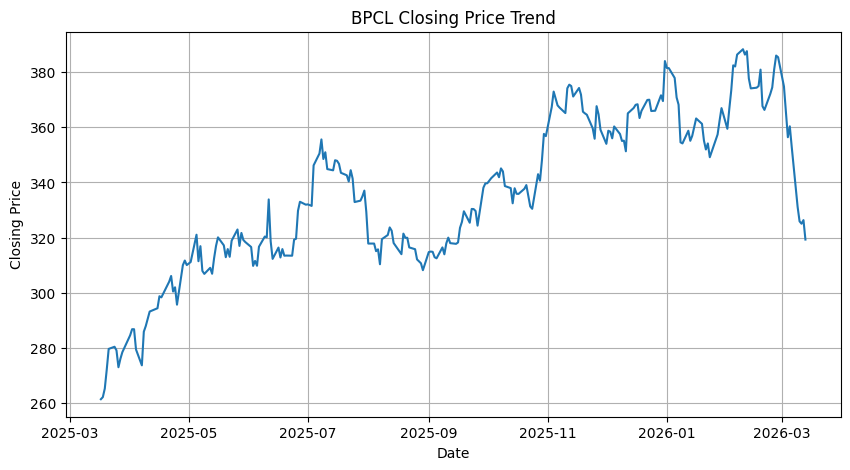

In [26]:
#(c) Visualize Closing Price Trend
plt.figure(figsize=(10,5))
plt.plot(df['CLOSE'])
plt.title("BPCL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid()

plt.savefig("price_trend.png")
plt.show()

#ADF Test (Stationarity)

In [30]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['CLOSE'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.605906500512211
p-value: 0.09178264838996192


Interpretation for report:
p < 0.05 → stationary
p > 0.05 → non-stationary

since p-value = 0.0917 > 0.05

The time series is NOT stationary


In [34]:
# If non-stationary:

df_diff = df.diff().dropna()
df = df.dropna()

#ACF and PACF Plots

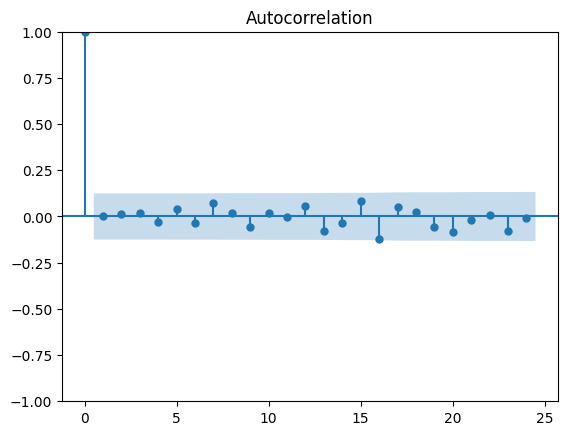

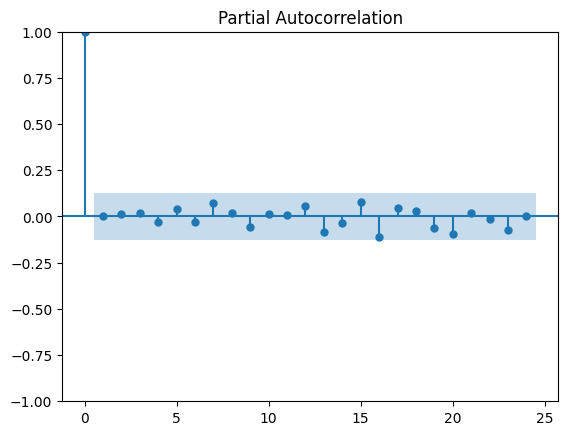

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plt.savefig("acf_plot.png")
plt.show()

plot_pacf(df_diff)
plt.savefig("pacf_plot.png")
plt.show()

#Train ARIMA Model


In [36]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['CLOSE'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  247
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -767.422
Date:                Tue, 17 Mar 2026   AIC                           1540.843
Time:                        15:21:08   BIC                           1551.359
Sample:                             0   HQIC                          1545.078
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0011     31.235   3.61e-05      1.000     -61.219      61.221
ma.L1          0.0011     31.231   3.52e-05      1.000     -61.211      61.213
sigma2        30.0171      2.076     14.456      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

#Forecast Next 30 Days

In [37]:
forecast = model_fit.forecast(steps=30)
print(forecast)

247    319.284304
248    319.284287
249    319.284287
250    319.284287
251    319.284287
252    319.284287
253    319.284287
254    319.284287
255    319.284287
256    319.284287
257    319.284287
258    319.284287
259    319.284287
260    319.284287
261    319.284287
262    319.284287
263    319.284287
264    319.284287
265    319.284287
266    319.284287
267    319.284287
268    319.284287
269    319.284287
270    319.284287
271    319.284287
272    319.284287
273    319.284287
274    319.284287
275    319.284287
276    319.284287
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


#Plot Forecast

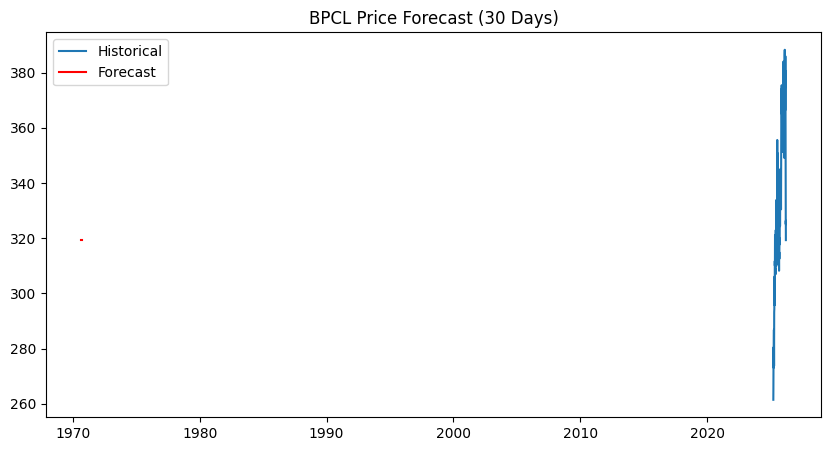

In [38]:
plt.figure(figsize=(10,5))

plt.plot(df['CLOSE'], label="Historical")
plt.plot(forecast, label="Forecast", color='red')

plt.legend()
plt.title("BPCL Price Forecast (30 Days)")

plt.savefig("forecast.png")
plt.show()

Interpretation:

The ARIMA model suggests a slight upward trend in BPCL stock prices over the next 30 days. However, fluctuations are present, indicating market volatility. The model captures general trends but may not fully account for external factors affecting stock prices.